### Approach 1 ML Linear Regression

In [1]:
import numpy as np # For numerical computation
import pandas as pd # Data manipulation
import seaborn as sns # plotting
import scipy.io # reading matlab files in python
from scipy import signal #signal processing
from scipy.fftpack import fft, dct #signal processing

from sklearn.linear_model import LinearRegression #linear regression model
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, train_test_split # cross validation split
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')

from matplotlib import pyplot as plt # For plotting graphs(Visualization)

import os # system-wide functions
os.listdir('E:\Kaggle_projects\Blood_Pressure_analysis\Blood_pressure_dataset')

['part_1.mat',
 'part_10.mat',
 'part_11.mat',
 'part_12.mat',
 'part_2.mat',
 'part_3.mat',
 'part_4.mat',
 'part_5.mat',
 'part_6.mat',
 'part_7.mat',
 'part_8.mat',
 'part_9.mat',
 'Samples']

In [2]:
def rmse(y_true, y_pred):
    """Computes the Root Mean Squared Error (RMSE)."""
    return np.sqrt(mean_squared_error(y_true, y_pred))

In [3]:
os.chdir('E:\Kaggle_projects\Blood_Pressure_analysis\Blood_pressure_dataset')

sample_file = scipy.io.loadmat(f'part_{1}.mat') # 返回字典
print(f'sample_file Data type: {type(sample_file)}')
print(f'sample_file keys:\n{sample_file.keys()}')

sample_file Data type: <class 'dict'>
sample_file keys:
dict_keys(['__header__', '__version__', '__globals__', 'p'])


In [4]:
sample_file

{'__header__': b'MATLAB 5.0 MAT-file, Platform: GLNXA64, Created on: Sat Jun  3 04:05:08 2017',
 '__version__': '1.0',
 '__globals__': [],
 'p': array([[array([[ 1.75953079e+00,  1.71847507e+00,  1.68426197e+00, ...,
                  1.64418377e+00,  1.60019550e+00,  1.56598240e+00],
                [ 6.70629552e+01,  6.93586281e+01,  7.53664529e+01, ...,
                  7.64410232e+01,  8.18138747e+01,  9.13873191e+01],
                [-6.06060606e-02, -7.52688172e-02, -7.03812317e-02, ...,
                 -1.00195503e-01, -9.04203324e-02, -4.54545455e-02]])   ,
         array([[ 2.40957967,  2.32942326,  2.23851417, ...,  1.24046921,
                  1.23069404,  1.21994135],
                [73.75459745, 73.1684682 , 72.53349484, ..., 99.15353167,
                 96.22288542, 93.19455095],
                [ 0.18475073,  0.17986315,  0.16959922, ...,  0.29472141,
                  0.31964809,  0.33968719]])                             ,
         array([[  1.21212121,   1.20136

In [5]:
test_sample = scipy.io.loadmat(f'part_{1}.mat')['p']
print(f'test_sample Data type: {type(test_sample)}')
print(f'test_sample shape/dimensions: {test_sample.shape}')

test_sample Data type: <class 'numpy.ndarray'>
test_sample shape/dimensions: (1, 1000)


In [6]:
test_sample_list = []
for i in range(12):
    test_sample = scipy.io.loadmat(f'part_{i+1}.mat')['p']
    test_sample_list.append(test_sample.shape)
print(test_sample_list)

[(1, 1000), (1, 1000), (1, 1000), (1, 1000), (1, 1000), (1, 1000), (1, 1000), (1, 1000), (1, 1000), (1, 1000), (1, 1000), (1, 1000)]


In [7]:
test_sample[0].shape

(1000,)

In [8]:
test_sample[0][0]

array([[  1.47116325,   1.43792766,   1.40371457, ...,   1.94037146,
          1.92179863,   1.90518084],
       [145.55543073, 145.99502767, 145.55543073, ..., 105.60095344,
        111.16918132, 115.66283892],
       [  0.48998534,   0.5       ,   0.5048852 , ...,   0.52491451,
          0.5       ,   0.48510015]])

In [9]:
test_sample[0][0].shape

(3, 13000)

In [10]:
len(test_sample[0][0][0])

13000

In [11]:
test_sample[0].shape

(1000,)

In [12]:
test_sample_2 = scipy.io.loadmat(f'part_{2}.mat')['p']
test_sample_2[0].shape

(1000,)

In [13]:
test_sample_2[0][0].shape

(3, 6000)

In [14]:
test_sample_2[0][2].shape

(3, 26000)

In [15]:
test_sample[0][114].shape

(3, 49000)

#### 每一个样本3通道（PPG, ABP, ECG），每个通道数据点个数不定，统计如下 

#### 1000个样本（记录1000次）

In [16]:
test_sample.shape

(1, 1000)

In [17]:
print(f"Total Samples: {len(test_sample[0])}")
print(f"Number of readings in each sample(column): {len(test_sample[0][0])}")
print(f"Number of samples in each reading(ECG): {len(test_sample[0][0][2])}")

temp_mat = test_sample[0, 999] # 选test_sample第999个record
temp_length = temp_mat.shape[1]
sample_size = 125


print(temp_length)
print((int)(temp_length/sample_size))

Total Samples: 1000
Number of readings in each sample(column): 3
Number of samples in each reading(ECG): 13000
2000
16


In [18]:
len_list = [test_sample[0, i].shape[1] for i in range(0, 1000)]

print(f"Minimum record length is: {min(len_list)}")
print(f"Maximum record length is: {max(len_list)}")

Minimum record length is: 1000
Maximum record length is: 74000


In [19]:
temp_mat.shape

(3, 2000)

#### sample size可通过分析R波峰为时间参考点确定（sample size/Fs = segment time）
#### CNN输入维度固定，必须用统一的片段长度
#### PPG振幅归一化：Stable trraining & improve convergence rate

#### Preprocessing: Removing recordings < 8 min (125 * 8 * 60 points) and ABP values > 200mmHg
#### 窗口大小8.192s (1024)，overlap 75% (768), 步长（256）

#### part1中删除短于8min的数据还剩120条recording
#### 12个mat file共12000条recording

In [40]:
remove_list = []

for i in range(1000):
    temp_mat = test_sample[0, i]
    if temp_mat.shape[1] < 8 * 60 * 125:
        remove_list.append(i)

print(remove_list)
print(len(remove_list))

[0, 1, 2, 3, 4, 5, 6, 7, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 22, 23, 24, 28, 30, 31, 33, 34, 35, 36, 37, 38, 39, 40, 42, 43, 44, 47, 48, 49, 50, 51, 52, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 65, 66, 67, 68, 69, 71, 72, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 90, 91, 92, 93, 94, 95, 96, 97, 101, 102, 105, 106, 109, 111, 113, 114, 116, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 216, 217, 218, 219, 222, 224, 225, 226, 227, 228, 229, 230, 231, 232, 233, 234, 235, 236, 237, 238, 239, 240, 241, 242, 244, 245, 246, 247, 248, 249, 250, 252, 253,

#### 删除短于8.192s的数据还剩880条

In [ ]:
remove_list = []

for i in range(1000):
    temp_mat = test_sample[0, i]
    if temp_mat.shape[1] < 1024:
        remove_list.append(i)

print(remove_list)
print(len(remove_list))

[87, 129, 130, 132, 134, 139, 143, 153, 155, 156, 157, 160, 166, 186, 200, 202, 203, 224, 225, 236, 241, 249, 252, 290, 293, 299, 300, 310, 311, 314, 331, 338, 351, 367, 373, 382, 383, 391, 426, 436, 462, 471, 488, 489, 490, 492, 493, 506, 512, 513, 514, 520, 531, 538, 541, 542, 546, 552, 566, 571, 636, 637, 640, 645, 648, 650, 657, 658, 659, 676, 679, 684, 686, 691, 696, 705, 706, 707, 709, 740, 745, 747, 750, 751, 770, 779, 782, 784, 789, 792, 793, 796, 798, 805, 816, 818, 820, 845, 864, 893, 898, 916, 917, 918, 920, 922, 925, 928, 935, 947, 953, 956, 961, 962, 975, 984, 985, 988, 991, 997]
120


In [36]:
save_list = []

for i in range(1000):
    temp_mat = test_sample[0, i]
    if temp_mat.shape[1] > 1024:
        save_list.append(i)

print(save_list)
print(len(save_list))

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 131, 133, 135, 136, 137, 138, 140, 141, 142, 144, 145, 146, 147, 148, 149, 150, 151, 152, 154, 158, 159, 161, 162, 163, 164, 165, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 201, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221, 222, 223, 226, 227, 228, 229, 230, 231, 232, 233, 234, 235, 237, 238, 239, 240, 242

In [37]:
processed_mat_1 = [test_sample[0, i] for i in save_list]
print(len(processed_mat_1))
processed_mat_1[0].shape

880


(3, 13000)

In [38]:
processed_mat_1

[array([[  1.47116325,   1.43792766,   1.40371457, ...,   1.94037146,
           1.92179863,   1.90518084],
        [145.55543073, 145.99502767, 145.55543073, ..., 105.60095344,
         111.16918132, 115.66283892],
        [  0.48998534,   0.5       ,   0.5048852 , ...,   0.52491451,
           0.5       ,   0.48510015]]),
 array([[  1.16226784,   1.14662757,   1.13685239, ...,   1.19550342,
           1.17497556,   1.15347019],
        [ 99.78850503,  98.61624653,  97.49283213, ..., 116.93278563,
         113.85560706, 110.19229924],
        [  0.48998534,   0.48998534,   0.48510015, ...,   0.4098681 ,
           0.42501221,   0.43991207]]),
 array([[ 2.01955034,  1.98240469,  1.95112414, ...,  2.53763441,
          2.5884653 ,  2.6226784 ],
        [63.35080324, 62.9112063 , 62.61814168, ..., 70.8727953 ,
         70.04244553, 69.55400448],
        [ 0.39496825,  0.42989741,  0.44992672, ...,  0.42501221,
          0.47997069,  0.56497313]]),
 array([[ 1.56402737,  1.54349951,  1.53

In [ ]:
save_list = []
for i in range(len(processed_mat_1)):
    if np.max(processed_mat_1[i][1]) < 200:
        save_list.append(i)

BPless_200 = [processed_mat_1[i] for i in save_list]
len(BPless_200)

880

In [23]:
sample_size = 125
ppg = []
for i in range(1000):
    temp_mat = test_sample[0, i] # 取test_sample第i个record
    temp_length = temp_mat.shape[1] # record长度
    for j in range((int)(temp_length/sample_size)): # 每125个点作为一个ppg信号片段，除法返回float，(int)强制转换整数
        temp_ppg = temp_mat[0, j*sample_size:(j+1)*sample_size] # 第0行为PPG信号，取125个数据点
        ppg.append(temp_ppg)

In [28]:
type(ppg)

list

In [29]:
len(ppg)

256488

In [ ]:
ppg[0].shape # 每个ppg信号片段长度为125，所有片段数量为len(ppg)，相乘即为展平后的总长度32061000

(125,)

In [30]:
len = 0
for i in range(1000):
    len += test_sample[0, i].shape[1]
print(len)

32061000


In [31]:
ecg = []
bp = []
sbp = [] #Systolic Blood Pressure
dbp = [] #Diastolic Blood Pressue
size = 125 #sample size

for i in range(1000):
    temp_mat = test_sample[0, i]
    temp_length = temp_mat.shape[1]
    for j in range((int)(temp_length/sample_size)):
        temp_ecg = temp_mat[2, j*size:(j+1)*size] # 第二行为ECG信号
        temp_bp = temp_mat[1, j*size:(j+1)*size] # 第一行为BP信号
        
        max_value = max(temp_bp)
        min_value = min(temp_bp)
        
        sbp.append(max_value)
        dbp.append(min_value)
        ecg.append(temp_ecg)
        bp.append(temp_bp)

In [38]:
# Reshaping the ecg, ppg and bp signal data into column vectors
ppg, ecg, bp = np.array(ppg).reshape(-1,1), np.array(ecg).reshape(-1,1), np.array(bp).reshape(-1,1)
sbp, dbp = np.array(sbp).reshape(-1,1), np.array(dbp).reshape(-1,1)
print(f'PPG_shape: {ppg.shape}\n ECG_shape: {ecg.shape}\n BP_shape: {bp.shape}')
print(f'Systolic-BP_shape: {sbp.shape},\n Diastolic-BP_shape: {dbp.shape}')

PPG_shape: (32061000, 1)
 ECG_shape: (32061000, 1)
 BP_shape: (32061000, 1)
Systolic-BP_shape: (256488, 1),
 Diastolic-BP_shape: (256488, 1)


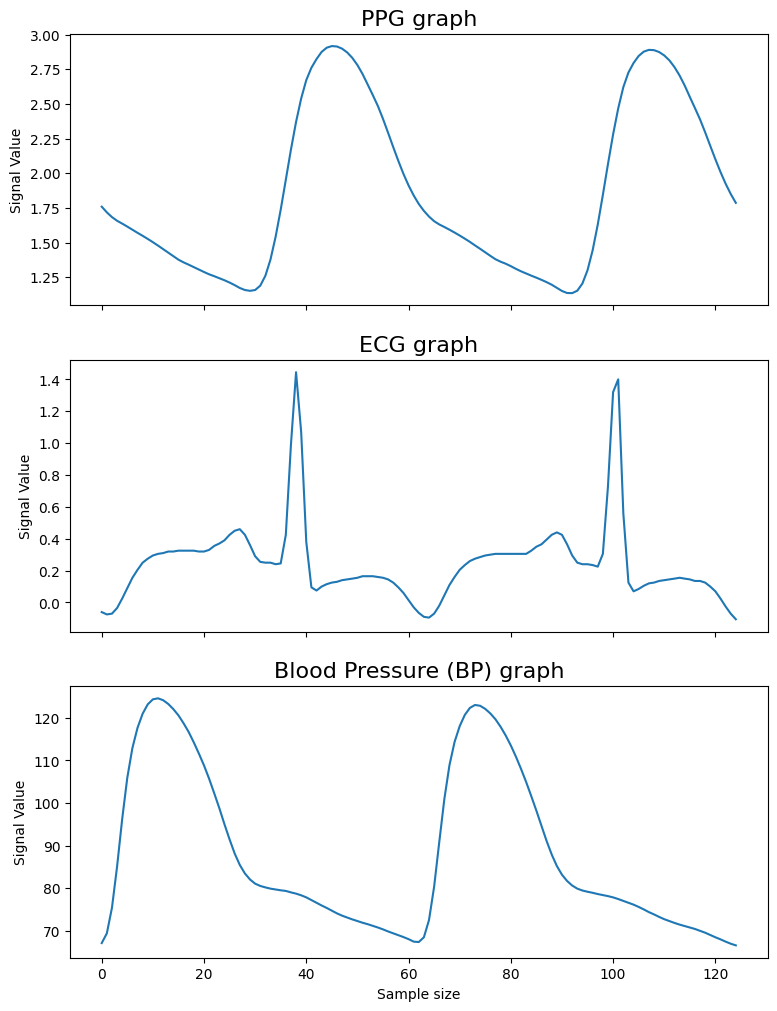

In [39]:
##plotting sample ppg, ecg and bp signals
##using a sample size of 125
fig, ax = plt.subplots(3,1, figsize=(9,12), sharex=True)

ax[0].set_title('PPG graph', fontsize=16)
ax[0].set_ylabel('Signal Value')
ax[0].plot(ppg[:125])

ax[1].set_title('ECG graph', fontsize=16)
ax[1].set_ylabel('Signal Value')
ax[1].plot(ecg[:125])

ax[2].set_title('Blood Pressure (BP) graph', fontsize=16)
ax[2].set_ylabel('Signal Value')
ax[2].set_xlabel('Sample size')
ax[2].plot(bp[:125])

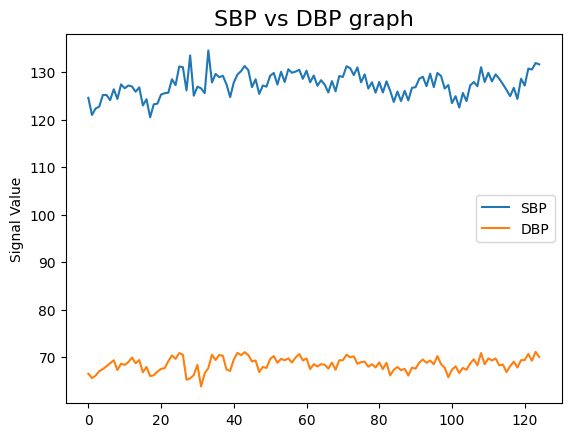

In [40]:
## Visualizing SBP and DBP
#fig, ax = plt.subplots(1,1, figsize=(9,12))

plt.title('SBP vs DBP graph', fontsize=16)
plt.ylabel('Signal Value')
plt.plot(sbp[:125])
plt.plot(dbp[:125])
plt.legend(['SBP', 'DBP'])

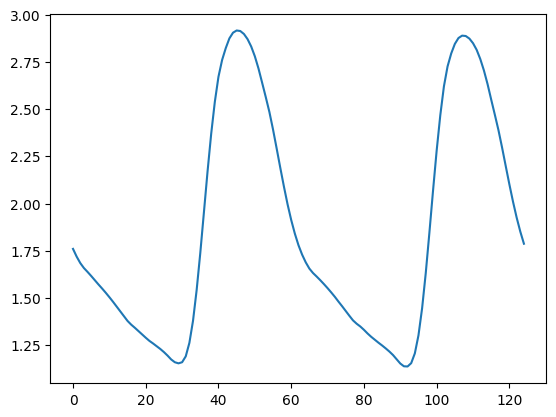

In [41]:
plt.plot(ppg[:125].squeeze())

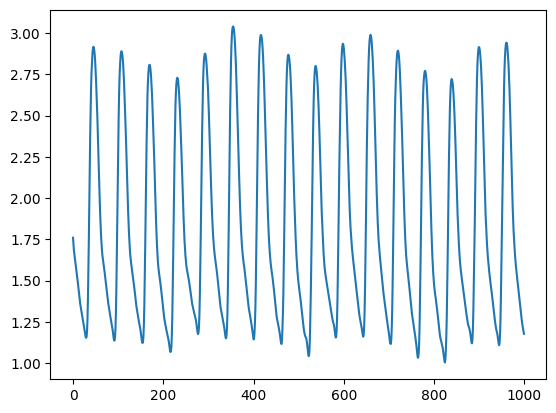

In [53]:
plt.plot(ppg[:1000].squeeze())

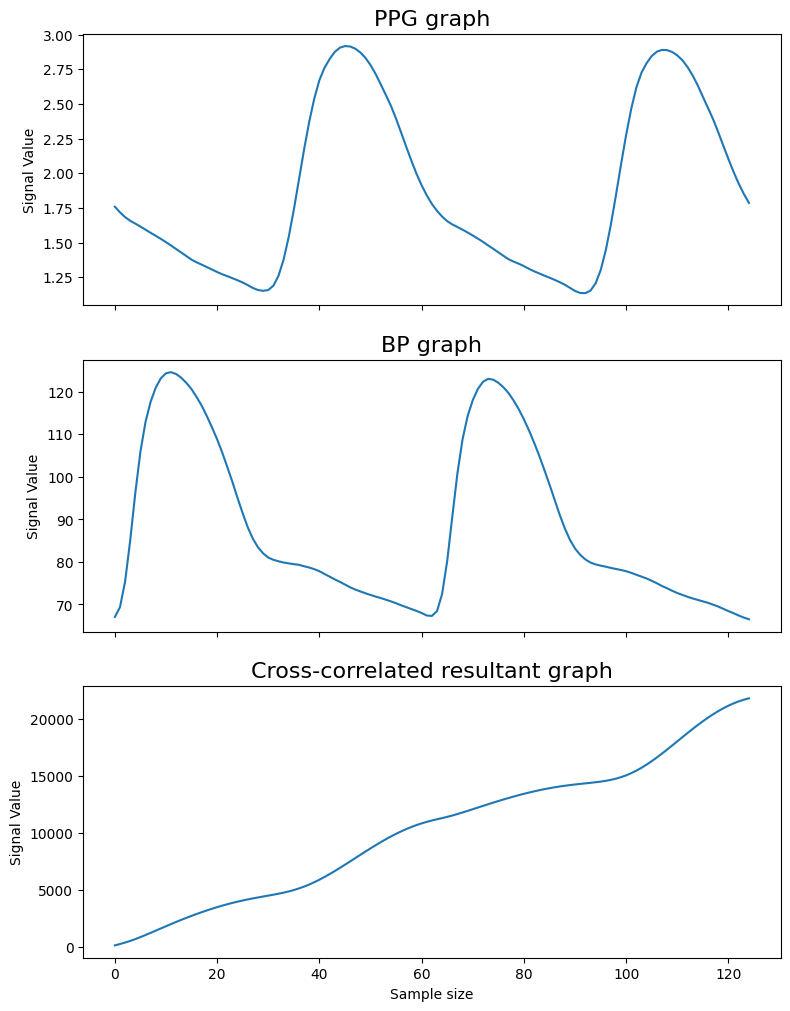

In [42]:
# Computing the cross correlation of ppg and bp signals
cross_corr = np.convolve(ppg[:125].squeeze(), bp[:125].squeeze(), mode='full')

fig, ax = plt.subplots(3,1, figsize=(9,12), sharex=True)

ax[0].set_title('PPG graph', fontsize=16)
ax[0].set_ylabel('Signal Value')
ax[0].plot(ppg[:125])

ax[1].set_title('BP graph', fontsize=16)
ax[1].set_ylabel('Signal Value')
ax[1].plot(bp[:125])

ax[2].set_title('Cross-correlated resultant graph', fontsize=16)
ax[2].set_ylabel('Signal Value')
ax[2].set_xlabel('Sample size')
ax[2].plot(cross_corr[:125])

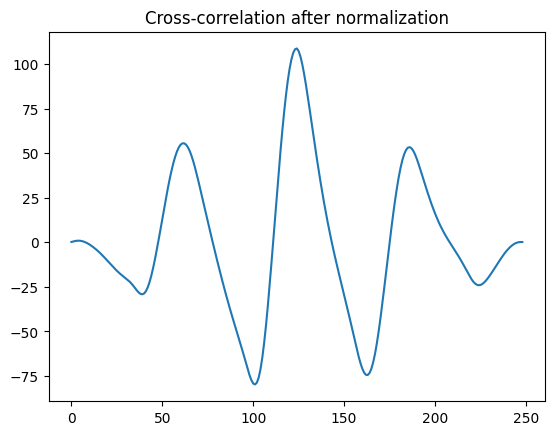

In [51]:
ppg_normalized = (ppg[:125].squeeze() - np.mean(ppg[:125].squeeze())) / np.std(ppg[:125].squeeze())
bp_normalized = (bp[:125].squeeze() - np.mean(bp[:125].squeeze())) / np.std(bp[:125].squeeze())
cross_corr = np.convolve(ppg_normalized, bp_normalized, mode='full')

plt.plot(cross_corr)
plt.title('Cross-correlation after normalization')
plt.show()

In [43]:
#Computing the discrete cosine transform (DCT)
cosine_transformed_array = dct(ppg)
error = rmse(bp.squeeze(), cosine_transformed_array.squeeze())
print(f'RMSE: {error}')

RMSE: 92.6029607182544


In [44]:
X_train, X_test, y_train, y_test = train_test_split(ppg, bp, test_size=0.30)

#### Using Linear Regressor

In [45]:
#Kfold cross-validation
folds = KFold(n_splits=5, shuffle=False)
scores = []
for i, (train_index, val_index) in enumerate(folds.split(X_train, y_train)):
    train_data, target = X_train[train_index], y_train[train_index]
    validation_data, val_target = X_train[val_index], y_train[val_index]
    
    model = LinearRegression()
    model.fit(train_data, target)
    #model = RandomForestRegressor(n_estimators=50,max_depth=5, n_jobs=-1, random_state=42)
    #model.fit(train_data[:100000], target[:100000].squeeze())  # training on few samples to save time.
    val_predictions = model.predict(validation_data)
    error = rmse(val_target, val_predictions)
    scores.append(error)
    print(f'Fold {i} RMSE: {error}')
print(f'Average RMSE over 5 folds: {np.mean(scores)}')

Fold 0 RMSE: 27.343567020928152
Fold 1 RMSE: 27.347006038031733
Fold 2 RMSE: 27.338049254771395
Fold 3 RMSE: 27.337072198999632
Fold 4 RMSE: 27.348570631807625
Average RMSE over 5 folds: 27.342853028907705


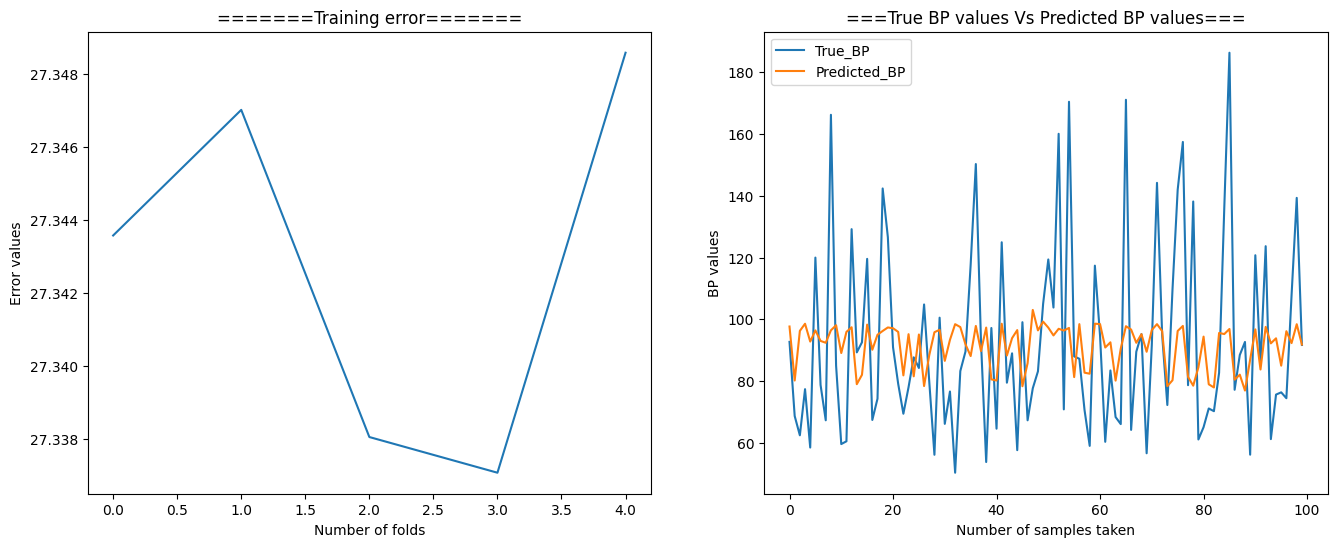

In [46]:
# Visualizing train error.
fig, ax = plt.subplots(1,2, figsize=(16,6))
ax[0].set_title("=======Training error=======")
ax[0].set_xlabel('Number of folds')
ax[0].set_ylabel('Error values')
ax[0].plot(scores)

# Visualize predicted BP and the True BP
ax[1].set_title("===True BP values Vs Predicted BP values===")
ax[1].set_xlabel('Number of samples taken')
ax[1].set_ylabel('BP values')
ax[1].plot(val_target[:100]) #only plotting 100 samples
ax[1].plot(val_predictions[:100])
ax[1].legend(['True_BP', 'Predicted_BP'])

In [47]:
# Predicting on the test set
test_predictions = model.predict(X_test[:1000000]) #predicting on the first 1million rows for speed.
test_error = rmse(y_test[:1000000], test_predictions)
print(f'Error on test set predictions: {test_error}')

Error on test set predictions: 27.32851013042951


#### Using Random Forest Regressor

In [48]:
folds = KFold(n_splits=5, shuffle=False)
scores = []
for i, (train_index, val_index) in enumerate(folds.split(X_train, y_train)):
    train_data, target = X_train[train_index], y_train[train_index]
    validation_data, val_target = X_train[val_index], y_train[val_index]
    
    # model = LinearRegression()
    # model.fit(train_data, target)
    model = RandomForestRegressor(n_estimators=50,max_depth=5, n_jobs=-1, random_state=42)
    model.fit(train_data[:100000], target[:100000].squeeze())  # training on few samples to save time.
    val_predictions = model.predict(validation_data)
    error = rmse(val_target, val_predictions)
    scores.append(error)
    print(f'Fold {i} RMSE: {error}')
print(f'Average RMSE over 5 folds: {np.mean(scores)}')

Fold 0 RMSE: 25.357092838411624
Fold 1 RMSE: 25.355165762333804
Fold 2 RMSE: 25.358179102487572
Fold 3 RMSE: 25.35021135742227
Fold 4 RMSE: 25.368283627993005
Average RMSE over 5 folds: 25.357786537729655


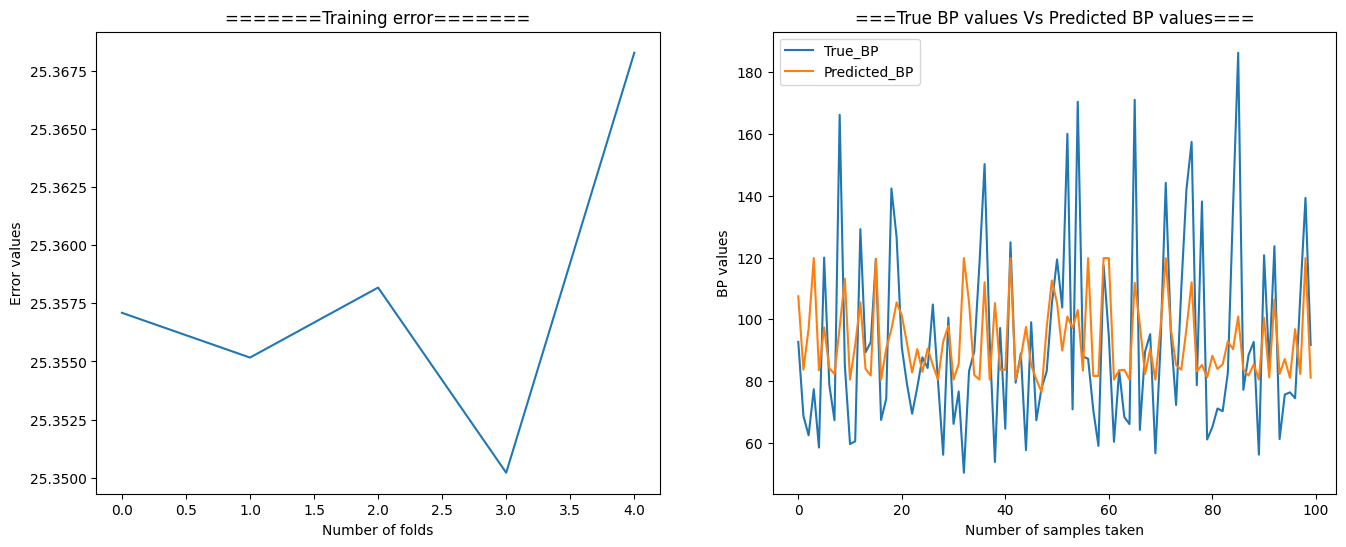

In [49]:
fig, ax = plt.subplots(1,2, figsize=(16,6))
ax[0].set_title("=======Training error=======")
ax[0].set_xlabel('Number of folds')
ax[0].set_ylabel('Error values')
ax[0].plot(scores)

# Visualize predicted BP and the True BP
ax[1].set_title("===True BP values Vs Predicted BP values===")
ax[1].set_xlabel('Number of samples taken')
ax[1].set_ylabel('BP values')
ax[1].plot(val_target[:100]) #only plotting 100 samples
ax[1].plot(val_predictions[:100])
ax[1].legend(['True_BP', 'Predicted_BP'])

In [50]:
test_predictions = model.predict(X_test[:1000000]) #predicting on the first 1million rows for speed.
test_error = rmse(y_test[:1000000], test_predictions)
print(f'Error on test set predictions: {test_error}')

Error on test set predictions: 25.345787468315915
